In [ ]:
# %load_ext autoreload
# %autoreload 2

In [ ]:
# for google colab

!pip install pypose
!pip install kornia

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/
!git clone https://github.com/MarcinJanis/SonarOdometry.git
%cd SonarOdometry

/content
Cloning into 'SonarOdometry'...
remote: Enumerating objects: 4491, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 4491 (delta 13), reused 16 (delta 5), pack-reused 4457 (from 3)
Receiving objects: 100% (4491/4491), 593.76 MiB | 17.66 MiB/s, done.
Resolving deltas: 100% (1596/1596), done.
Updating files: 100% (254/254), done.
/content/SonarOdometry


In [ ]:
import os
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F


import numpy as np
import cv2
from scipy.spatial.transform import Rotation as R

from box import Box
import yaml

import matplotlib.pyplot as plt
from tqdm import tqdm

import random
import time

root_dir = os.path.abspath('../..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.data_loader.evaluation_data_generator import DataGenerator
from src.models.patchifier import Patchifier
from src.data_loader.metrics import eval_metrics_2d


In [ ]:
# Path to root directory
# root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry'
root_dir = '/content/SonarOdometry'

# Configuration Files
model_config_pth = os.path.join(root_dir, 'config/model2d.yaml')
sonar_config_pth = os.path.join(root_dir, 'config/sonar.yaml')

# Path to evaluation dataset
# data_root_dir = os.path.join(root_dir, 'SonarOdometryDataset/selfsupervised/val/seq_15')
data_root_dir = '/content/drive/MyDrive/SonarOdometryDataset/SonarOdometryDataset_sample/SonarOdometryDataset_sample/seq_15'
# data_root_dir = '/content/drive/MyDrive/SonarOdometryDataset/SonarOdometryDataset_sample/test_scenarios/seq_2'
# data_root_dir = '/content/drive/MyDrive/SonarOdometryDataset/aracati2017/aracati2017'


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(model_config_pth, "r") as f:
            model_config = Box(yaml.safe_load(f))

with open(sonar_config_pth, "r") as f:
            sonar_config = Box(yaml.safe_load(f))

from src.models.utils import ExtrinsicsCalib
extrinsics_calib = ExtrinsicsCalib(T = [sonar_config.position.x, sonar_config.position.y, sonar_config.position.z],
                                   R = [sonar_config.position.roll, sonar_config.position.pitch, sonar_config.position.yaw])

# Import data generator
from src.data_loader.transforms import SonarDatasetTranforms

fls_resolution = (model_config.input_dimensions.polar_height , model_config.input_dimensions.polar_width ) # for own ds
# fls_resolution = (model_config.CART_FLS_INPUT_HEIGHT, model_config.CART_FLS_INPUT_WIDTH) # for aracati

data_generator = DataGenerator(data_root_dir, device, fls_resolution=fls_resolution, transforms = SonarDatasetTranforms, calibration = None)
data_lenght = data_generator.get_len()

print(f'Data generator initialized.')
print(f'Data series lenght: {data_lenght}')

# Import model
from src.models.odometry2d_new import sonar_odometry

Data generator initialized.
Data series lenght: 1000


In [ ]:
# def visualize_loftr_matches(visu_dict, current_idx, kf_idx, show_visualization=True):
#     """
#     Opcjonalne narzędzie rysujące połączenia między Klatką Kluczową a Klatką Bieżącą.
#     Inliers (akceptowane przez RANSAC) -> Zielone
#     Outliers (odrzucone) -> Czerwone
#     """
#     if not show_visualization or 'kf_tensor_cpu' not in visu_dict:
#         return

#     img0 = visu_dict['kf_tensor_cpu'].squeeze()
#     img1 = visu_dict['curr_tensor_cpu'].squeeze()

#     # Konwersja na RGB do rysowania kolorowych linii
#     img0_rgb = cv2.cvtColor((img0 * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
#     img1_rgb = cv2.cvtColor((img1 * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)

#     h, w = img0_rgb.shape[:2]
#     combined_img = np.concatenate((img0_rgb, img1_rgb), axis=1)

#     fig, ax = plt.subplots(figsize=(15, 6))
#     ax.imshow(combined_img)

#     mkpts0 = visu_dict['mkpts_ref']
#     mkpts1 = visu_dict['mkpts_curr']
#     inlier_mask = visu_dict['inlier_mask']

#     if len(mkpts0) > 0:
#         for i, (pt0, pt1) in enumerate(zip(mkpts0, mkpts1)):
#             x0, y0 = pt0
#             x1, y1 = pt1[0] + w, pt1[1]  # Przesunięcie x dla drugiego obrazka

#             # Kolorowanie: inliers = zielony, outliers = czerwony
#             is_inlier = inlier_mask[i] if inlier_mask is not None and len(inlier_mask) > i else False
#             color = 'lime' if is_inlier else 'red'
#             alpha = 0.8 if is_inlier else 0.3
#             linewidth = 1.0 if is_inlier else 0.5

#             ax.plot([x0, x1], [y0, y1], color=color, alpha=alpha, linewidth=linewidth)
#             ax.scatter(x0, y0, color=color, s=8, zorder=3)
#             ax.scatter(x1, y1, color=color, s=8, zorder=3)

#     status_color = "green" if visu_dict['status'] == 'OK' else "red"
#     title = (f"Frame Match: KF ({kf_idx}) -> Curr ({current_idx}) | "
#              f"Status: {visu_dict['status']} | "
#              f"Matches: {visu_dict['matches_total']} | ")
#             #  f"Inliers: {visu_dict['inliers_abs']} ({visu_dict['inliers_ratio']:.1%})")

#     ax.set_title(title, color=status_color, fontsize=12, fontweight='bold')
#     ax.axis('off')
#     plt.tight_layout()
#     plt.show()


import cv2
import numpy as np
from google.colab.patches import cv2_imshow

def visualize_loftr_matches(visu_dict, current_idx, kf_idx, show_visualization=True):
    """
    Kuloodporna wizualizacja dla Google Colab.
    Odporna na puste klatki, awarie trackingu i błędy typów zmiennoprzecinkowych.
    """
    if visu_dict is None or 'combined_imgs' not in visu_dict:
        print(f"⚠️ Brak obrazu do wizualizacji dla klatki {current_idx}")
        return

    combined_img = visu_dict['combined_imgs'].copy()

    # ZABEZPIECZENIE 1: Wymuszenie formatu uint8.
    # Rysowanie OpenCV na floatach w Colabie często kończy się ukrytym błędem (OOM lub TypeError)
    if combined_img.dtype != np.uint8:
        if combined_img.max() <= 1.0:
            combined_img = (combined_img * 255).astype(np.uint8)
        else:
            combined_img = combined_img.astype(np.uint8)

    h, w = combined_img.shape[:2]
    img_w = w // 2

    pts1 = visu_dict.get('pts1', [])
    pts2 = visu_dict.get('pts2', [])

    # ZABEZPIECZENIE 2: Rysujemy tylko wtedy, gdy system fizycznie wypluł jakieś punkty
    if pts1 is not None and len(pts1) > 0 and pts2 is not None and len(pts2) > 0:
        for pt1, pt2 in zip(pts1, pts2):
            try:
                x0, y0 = int(pt1[0]), int(pt1[1])
                x1, y1 = int(pt2[0]) + img_w, int(pt2[1])

                color = (0, 255, 0)
                cv2.line(combined_img, (x0, y0), (x1, y1), color, 1)
                cv2.circle(combined_img, (x0, y0), 3, color, -1)
                cv2.circle(combined_img, (x1, y1), 3, color, -1)
            except Exception:
                pass # Ignorujemy pojedyncze zepsute współrzędne

    # Bezpieczne pobieranie statusów z obsługą braku klucza
    step_is_valid = visu_dict.get('step_is_valid', False)
    status_emoji = "🟢" if step_is_valid else "🔴"

    print(f"\n{status_emoji} Frame Match: KF ({kf_idx}) -> Curr ({current_idx})")
    print(f"Inliers: {visu_dict.get('inliers_abs', 0)} | "
          f"Tx: {visu_dict.get('tx_sonar', 0.0):.2f} | Ty: {visu_dict.get('ty_sonar', 0.0):.2f} | "
          f"Theta: {np.degrees(visu_dict.get('theta', 0.0)):.2f}°")

    cv2_imshow(combined_img)

In [ ]:
# Parametry kontrolujące wizualizację
SHOW_MATCHES_VISUALIZATION = False

model = sonar_odometry(
    model_config=model_config,
    sonar_config=sonar_config,
    device=device,
    depth_compesation=True,
    key_frames=True,
    input_img_format='polar',
    ref_frame_orient='sim',
    # use_fls_filter=True,
    # ---
    # use_spatial_bucketing=False,
    # use_weighted_kabsch=False,
    # use_range_masking=False
)

# model.min_inliers_abs = 6
# model.min_inliers_ratio = 0.02
model.ransac_thresh = 2.0

start_idx = 170
max_iter = 600
stride = 1

# Data containers
gt_xy = []
pred_xy = []
metrics_local = {
    'tx_pred': [], 'tx_gt': [],
    'ty_pred': [], 'ty_gt': [],
    'yaw_pred': [], 'yaw_gt': []
}


if hasattr(extrinsics_calib, 'se3_s2r') and isinstance(extrinsics_calib.se3_s2r, torch.Tensor) and extrinsics_calib.se3_s2r.device != device:
    extrinsics_calib.se3_s2r = extrinsics_calib.se3_s2r.to(device)
if hasattr(extrinsics_calib, 'se3_r2s') and isinstance(extrinsics_calib.se3_r2s, torch.Tensor) and extrinsics_calib.se3_r2s.device != device:
    extrinsics_calib.se3_r2s = extrinsics_calib.se3_r2s.to(device)

# Set initial state
t, frame, pose_gt, depth = data_generator.get_sample(start_idx, return_visu=False, return_depth=True)

# Init pose (x, y)
init_pose_gt_np = pose_gt.detach().cpu().numpy()
init_xy = init_pose_gt_np[0:2]
gt_xy.append(init_xy)

# Init azimuth
rot_init = R.from_quat(init_pose_gt_np[3:7])
euler_init = rot_init.as_euler('zyx', degrees=False)
init_azimuth = euler_init[0] # yaw
print(f'Init state: {init_xy}, azimuth: {init_azimuth}')

pred_xy.append(np.concatenate((init_xy, np.array([init_azimuth])), axis=-1))

init_frame = frame.squeeze(1).to(device)
init_depth = depth.to(device) if depth is not None else None

# --- Inicjalizacja zgodna z najnowszą sygnaturą ---
model.set_init_state(
    init_x=init_xy[0],
    init_y=init_xy[1],
    init_azimuth=init_azimuth,
    init_frame=init_frame,
    init_depth=init_depth
)

# --- Zmienne do śledzenia Klatki Kluczowej (GT) ---
kf_idx = start_idx
kf_pose_gt = init_pose_gt_np
kf_yaw = init_azimuth

# --- MAIN LOOP ---
for i in tqdm(range(start_idx + stride, start_idx + max_iter*stride, stride), desc="Sonar odometry"):

    t, frame, pose_gt, depth = data_generator.get_sample(i, return_visu=False, return_depth=True)

    # Get actual GT data
    curr_pose_gt = pose_gt.detach().cpu().numpy()
    curr_x, curr_y = curr_pose_gt[0], curr_pose_gt[1]
    rot_curr = R.from_quat(curr_pose_gt[3:7])
    curr_yaw = rot_curr.as_euler('zyx', degrees=False)[0]

    # Predict (Zaktualizowane nazwy argumentów: frame i depth)
    pred_pose, pred_azimuth, visu = model(
        frame=frame.squeeze(1).to(device),
        depth=depth.to(device) if depth is not None else None,
        return_visu=True
    )

    # Opcjonalne narzędzie wizualizujące RANSAC i okno dopasowań
    if SHOW_MATCHES_VISUALIZATION:
        visualize_loftr_matches(visu, current_idx=i, kf_idx=kf_idx, show_visualization=True)


    # Global pose difference
    dx_gt_global = curr_x - kf_pose_gt[0]
    dy_gt_global = curr_y - kf_pose_gt[1]

    # Global rotation difference [-pi, pi]
    dyaw_gt = np.arctan2(np.sin(curr_yaw - kf_yaw), np.cos(curr_yaw - kf_yaw))

    # Transform global pose difference to key frame reference frame
    tx_gt_local = np.cos(kf_yaw) * dx_gt_global + np.sin(kf_yaw) * dy_gt_global
    ty_gt_local = -np.sin(kf_yaw) * dx_gt_global + np.cos(kf_yaw) * dy_gt_global

    # Get prediction details
    pred_tx, pred_ty, pred_dyaw = visu['tx_mapped'], visu['ty_mapped'], visu['theta']
    pred_gx, pred_gy, pred_gyaw = visu['global_pose']

    # Kolorowanie statusu do diagnostyki terminala
    status_str = f"\033[92mOK\033[0m" if visu.get('step_is_valid', True) else f"\033[91mCVM_FALLBACK\033[0m"

    print(f"\n=======================================================================")
    print(f" Frame matching: [(KF): {kf_idx} ---> Actual: {i}] | Status: {status_str}")
    print(f" LoFTR matches total: {visu['matches_total']} | confidence: {visu['mean_matched_confidence']:.3f} | RANSAC Inliers: {visu['inliers_abs']} ({visu['inliers_ratio']:.2%})")
    print(f"--- Local transformation ---")
    print(f"  PRED -> tx: {pred_tx:+.5f} m, ty: {pred_ty:+.5f} m, yaw: {pred_dyaw:+.5f} rad")
    print(f"  GT   -> tx: {tx_gt_local:+.5f} m, ty: {ty_gt_local:+.5f} m, yaw: {dyaw_gt:+.5f} rad")
    print(f"  ERR  -> tx: {pred_tx-tx_gt_local:+.5f} m, ty: {pred_ty-ty_gt_local:+.5f} m, yaw: {pred_dyaw-dyaw_gt:+.5f} rad")
    print(f"--- Global pose ---")
    print(f"  PRED ->  X: {pred_gx:+.5f},  Y: {pred_gy:+.5f}, Yaw: {pred_gyaw:+.5f}")
    print(f"  GT   ->  X: {curr_x:+.5f},  Y: {curr_y:+.5f}, Yaw: {curr_yaw:+.5f}")

    kf_status = "\033[96mActualisation (new kf)\033[0m" if visu['key_frame_detected'] else "Waiting for kf"
    print(f"--- Keyframe state ---")
    print(f"  Traj from kf: {visu['displacement']:.4f} m, Rot from kf: {visu['azimuth_diff']:.4f} rad -> {kf_status}\n")

    if visu['key_frame_detected']:
        kf_idx = i
        kf_pose_gt = curr_pose_gt
        kf_yaw = curr_yaw


    metrics_local['tx_pred'].append(pred_tx)
    metrics_local['tx_gt'].append(tx_gt_local)
    metrics_local['ty_pred'].append(pred_ty)
    metrics_local['ty_gt'].append(ty_gt_local)
    metrics_local['yaw_pred'].append(pred_dyaw)
    metrics_local['yaw_gt'].append(dyaw_gt)

    gt_xy.append(pose_gt[0:2].detach().cpu().numpy())
    pred_xy.append(np.concatenate((np.array(pred_pose), np.array([pred_azimuth])), axis=-1))

Init state: [ 7.548 -3.648], azimuth: -2.9466093956377675


Sonar odometry:   0%|          | 1/599 [00:00<05:30,  1.81it/s]


 Frame matching: [(KF): 170 ---> Actual: 171] | Status: OK
 LoFTR matches total: 180 | confidence: 0.990 | RANSAC Inliers: 180 (100.00%)
--- Local transformation ---
  PRED -> tx: +0.24991 m, ty: -0.01345 m, yaw: -0.00032 rad
  GT   -> tx: +0.36102 m, ty: +0.01127 m, yaw: +0.00003 rad
  ERR  -> tx: -0.11111 m, ty: -0.02471 m, yaw: -0.00036 rad
--- Global pose ---
  PRED ->  X: +7.30022,  Y: -3.68323, Yaw: -2.94693
  GT   ->  X: +7.19600,  Y: -3.72900, Yaw: -2.94658
--- Keyframe state ---
  Traj from kf: 0.2503 m, Rot from kf: 0.0003 rad -> Waiting for kf



Sonar odometry:   0%|          | 2/599 [00:00<04:28,  2.22it/s]


 Frame matching: [(KF): 170 ---> Actual: 172] | Status: OK
 LoFTR matches total: 161 | confidence: 0.974 | RANSAC Inliers: 161 (100.00%)
--- Local transformation ---
  PRED -> tx: +0.37174 m, ty: -0.04407 m, yaw: -0.00008 rad
  GT   -> tx: +0.70401 m, ty: +0.01896 m, yaw: -0.00189 rad
  ERR  -> tx: -0.33227 m, ty: -0.06303 m, yaw: +0.00181 rad
--- Global pose ---
  PRED ->  X: +7.17477,  Y: -3.67679, Yaw: -2.94669
  GT   ->  X: +6.86100,  Y: -3.80300, Yaw: -2.94850
--- Keyframe state ---
  Traj from kf: 0.3743 m, Rot from kf: 0.0001 rad -> Waiting for kf



...


 Frame matching: [(KF): 766 ---> Actual: 767] | Status: OK
 LoFTR matches total: 156 | confidence: 0.905 | RANSAC Inliers: 156 (97.50%)
--- Local transformation ---
  PRED -> tx: +0.24441 m, ty: -0.00266 m, yaw: +0.01963 rad
  GT   -> tx: +0.21912 m, ty: -0.01163 m, yaw: +0.02248 rad
  ERR  -> tx: +0.02530 m, ty: +0.00898 m, yaw: -0.00285 rad
--- Global pose ---
  PRED ->  X: -35.28572,  Y: +14.36533, Yaw: -0.78614
  GT   ->  X: -42.44100,  Y: +17.66900, Yaw: -0.92752
--- Keyframe state ---
  Traj from kf: 0.2444 m, Rot from kf: 0.0196 rad -> Actualisation (new kf)



Sonar odometry: 100%|█████████▉| 598/599 [09:03<00:00,  1.13it/s]


 Frame matching: [(KF): 767 ---> Actual: 768] | Status: OK
 LoFTR matches total: 147 | confidence: 0.887 | RANSAC Inliers: 147 (87.50%)
--- Local transformation ---
  PRED -> tx: +0.06941 m, ty: +0.01971 m, yaw: +0.02132 rad
  GT   -> tx: +0.21680 m, ty: -0.01255 m, yaw: +0.02248 rad
  ERR  -> tx: -0.14739 m, ty: +0.03226 m, yaw: -0.00116 rad
--- Global pose ---
  PRED ->  X: -35.22273,  Y: +14.33013, Yaw: -0.76482
  GT   ->  X: -42.32100,  Y: +17.48800, Yaw: -0.90504
--- Keyframe state ---
  Traj from kf: 0.0722 m, Rot from kf: 0.0213 rad -> Actualisation (new kf)



Sonar odometry: 100%|██████████| 599/599 [09:04<00:00,  1.10it/s]


 Frame matching: [(KF): 768 ---> Actual: 769] | Status: OK
 LoFTR matches total: 160 | confidence: 0.894 | RANSAC Inliers: 160 (97.56%)
--- Local transformation ---
  PRED -> tx: +0.35599 m, ty: -0.00792 m, yaw: +0.01828 rad
  GT   -> tx: +0.21377 m, ty: -0.01276 m, yaw: +0.02242 rad
  ERR  -> tx: +0.14222 m, ty: +0.00485 m, yaw: -0.00414 rad
--- Global pose ---
  PRED ->  X: -34.97136,  Y: +14.07793, Yaw: -0.74654
  GT   ->  X: -42.19900,  Y: +17.31200, Yaw: -0.88262
--- Keyframe state ---
  Traj from kf: 0.3561 m, Rot from kf: 0.0183 rad -> Actualisation (new kf)



             Odometry Evaluation Metrics (SOTA format)              
Metric                         |   Absolute [m] |    Relative [%]
--------------------------------------------------------------------
Total Trajectory Length        |     137.4670 m |              - 
Absolute Trajectory Err (ATE)  |       8.6947 m |        6.3249 %
Final Position Drift           |       7.9182 m |        5.7601 %
Relative Translation Err (RTE) |       0.1190 m |       69.7241 %


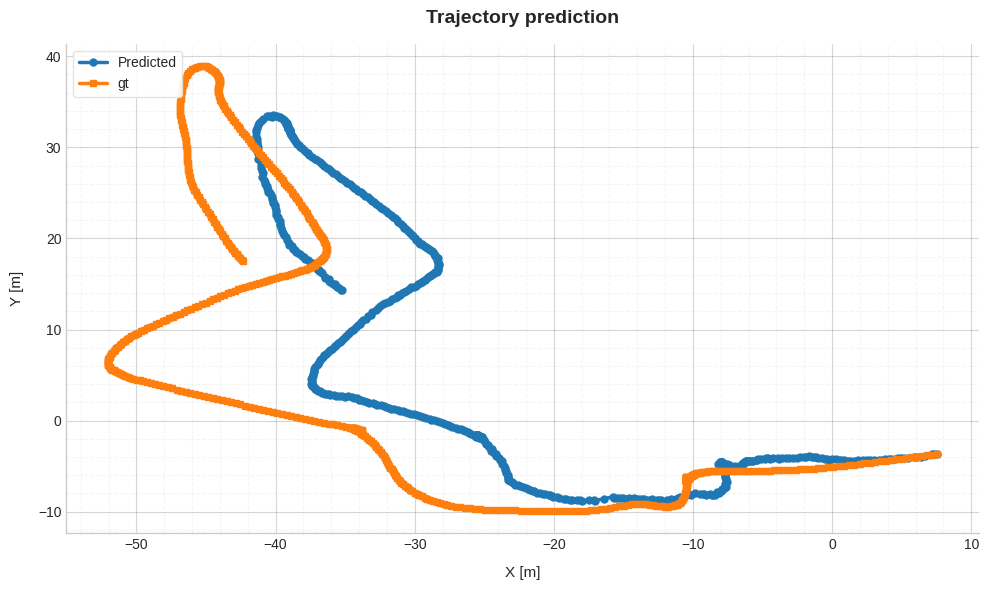

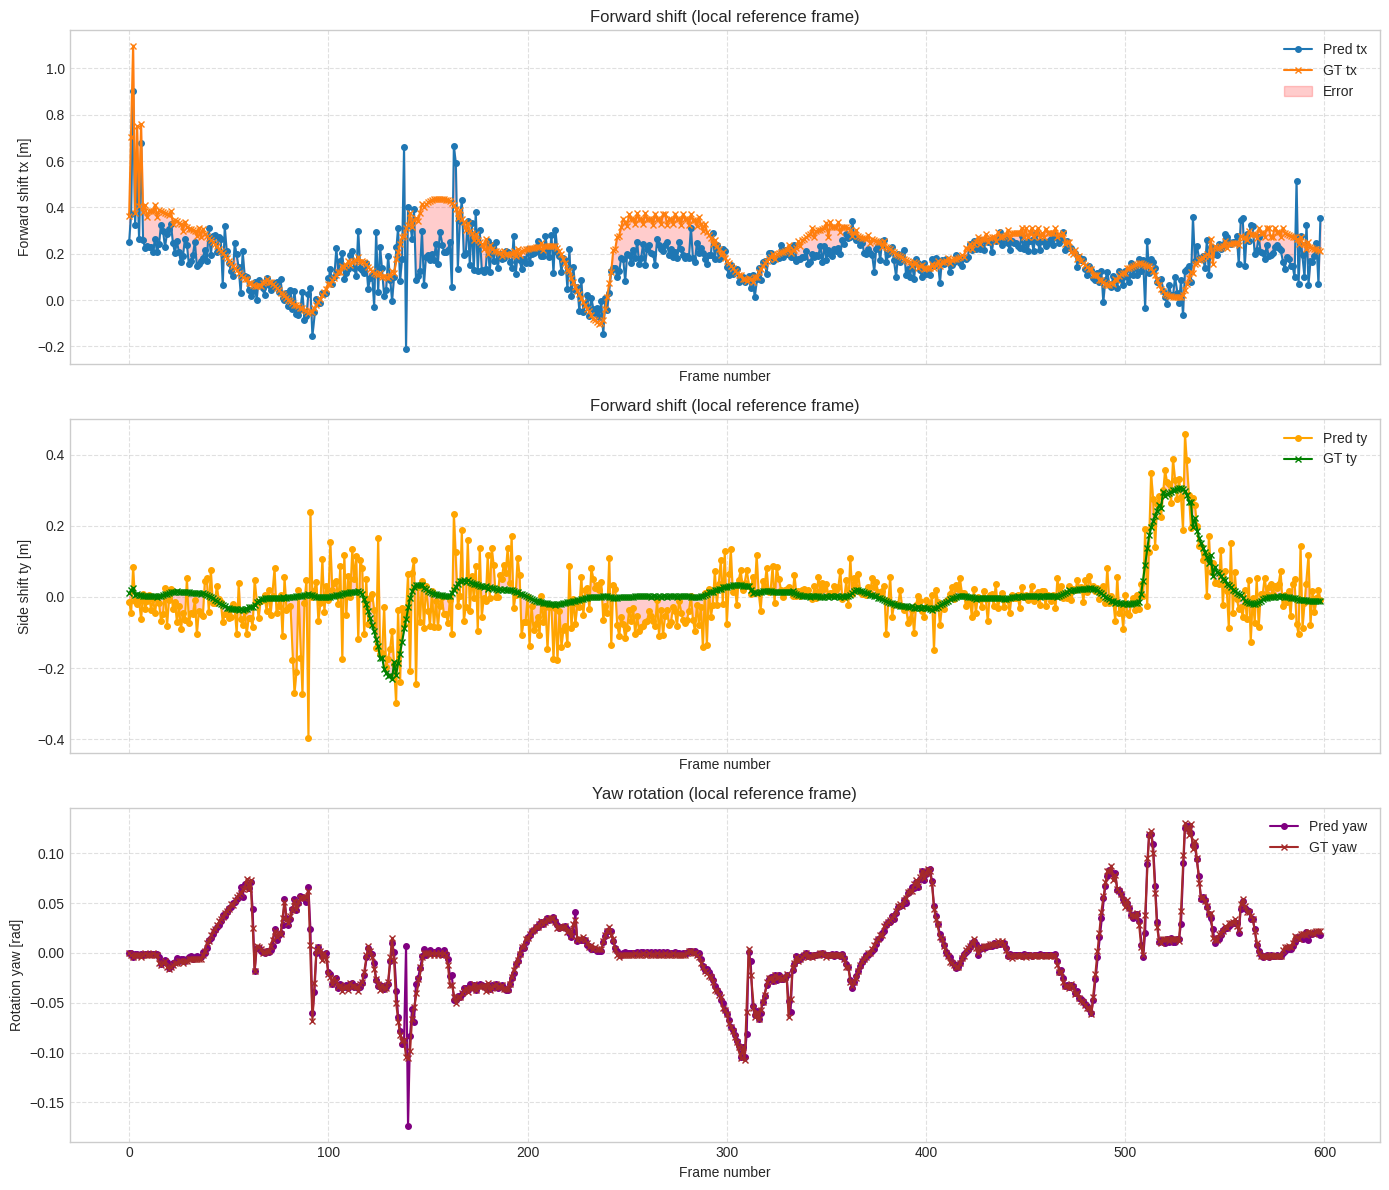

In [ ]:
# === visualise results ===

gt_xy_np = np.array(gt_xy)
pred_xy_np = np.array(pred_xy)

n = gt_xy_np.shape[0]

# --- metrics ---
metrics = eval_metrics_2d(pred_xy_np[:,:2], gt_xy_np) # Only compare x,y for ATE/RPE

# print('='*50)
# print('Metrics')
# print(f'Absolute trajectory error: {ATE} [m]')
# print(f'Relative pose error: {RPE} [m]')
# print('='*50)

# --- trajectory ---

start = 0
end = -1

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

ax.plot(pred_xy_np[start:end, 0], pred_xy_np[start:end, 1], label='Predicted', linewidth=2.5, marker='o', markersize=5)
ax.plot(gt_xy_np[start:end, 0], gt_xy_np[start:end, 1], label='gt', linewidth=2.5, marker='s', markersize=5)

ax.minorticks_on()
ax.grid(visible=True, which='major', color='#999999', linestyle='-', alpha=0.4)
ax.grid(visible=True, which='minor', color='#cccccc', linestyle='--', alpha=0.2)

ax.set_title('Trajectory prediction', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('X [m]', fontsize=11, labelpad=10)
ax.set_ylabel('Y [m]', fontsize=11, labelpad=10)

ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#e0e0e0', framealpha=0.9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout()

plt.show()

fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
frames_num = np.arange(len(metrics_local['tx_pred']))

# Wykres TX
axs[0].plot(frames_num, metrics_local['tx_pred'], label='Pred tx', marker='o', markersize=4)
axs[0].plot(frames_num, metrics_local['tx_gt'], label='GT tx', marker='x', markersize=4)
axs[0].fill_between(frames_num, metrics_local['tx_pred'], metrics_local['tx_gt'], color='red', alpha=0.2, label='Error')
axs[0].set_ylabel('Forward shift tx [m]')
axs[0].set_xlabel('Frame number')
axs[0].set_title('Forward shift (local reference frame)')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()

# Wykres TY
axs[1].plot(frames_num, metrics_local['ty_pred'], label='Pred ty', marker='o', markersize=4, color='orange')
axs[1].plot(frames_num, metrics_local['ty_gt'], label='GT ty', marker='x', markersize=4, color='green')
axs[1].fill_between(frames_num, metrics_local['ty_pred'], metrics_local['ty_gt'], color='red', alpha=0.2)
axs[1].set_ylabel('Side shift ty [m]')
axs[1].set_xlabel('Frame number')
axs[1].set_title('Forward shift (local reference frame)')
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend()

# Wykres YAW
axs[2].plot(frames_num, metrics_local['yaw_pred'], label='Pred yaw', marker='o', markersize=4, color='purple')
axs[2].plot(frames_num, metrics_local['yaw_gt'], label='GT yaw', marker='x', markersize=4, color='brown')
axs[2].fill_between(frames_num, metrics_local['yaw_pred'], metrics_local['yaw_gt'], color='red', alpha=0.2)
axs[2].set_ylabel('Rotation yaw [rad]')
axs[2].set_title('Yaw rotation (local reference frame)')
axs[2].set_xlabel('Frame number')
axs[2].grid(True, linestyle='--', alpha=0.6)
axs[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# print('--- Data Generator Sample Check ---')
# for i in range(start_idx, start_idx + min(max_iter, 5), stride): # Check first 5 samples
#     t_check, frame_check, pose_gt_check, depth_check = data_generator.get_sample(i, return_visu=False, return_depth=True)
#     print(f"Iteration {i}:")
#     print(f"  t type: {type(t_check)}, shape: {t_check.shape if hasattr(t_check, 'shape') else 'N/A'}")
#     print(f"  frame type: {type(frame_check)}, shape: {frame_check.shape}")
#     print(f"  pose_gt type: {type(pose_gt_check)}, shape: {pose_gt_check.shape}")
#     print(f"  depth type: {type(depth_check)}, shape: {depth_check.shape}")
# print('--- End Data Generator Sample Check ---')

In [ ]:

# # --- trajectory ---
# plt.style.use('seaborn-v0_8-whitegrid')
# fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# ax.plot(pred_xy_np[:, 0], pred_xy_np[:, 1], label='Predicted', linewidth=2.5, marker='o', markersize=5)
# ax.plot(gt_xy_np[:, 0], gt_xy_np[:, 1], label='gt', linewidth=2.5, marker='s', markersize=5)

# ax.minorticks_on()
# ax.grid(visible=True, which='major', color='#999999', linestyle='-', alpha=0.4)
# ax.grid(visible=True, which='minor', color='#cccccc', linestyle='--', alpha=0.2)

# ax.set_title('Trajectory prediction', fontsize=14, fontweight='bold', pad=15)
# ax.set_xlabel('X [m]', fontsize=11, labelpad=10)
# ax.set_ylabel('Y [m]', fontsize=11, labelpad=10)

# ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#e0e0e0', framealpha=0.9)

# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_color('#cccccc')
# ax.spines['bottom'].set_color('#cccccc')

# plt.tight_layout()

# plt.show()

In [ ]:
# # save prediction to file
# import csv

# n = pred_xy_np.shape[0]
# filename = os.path.join(data_root_dir, 'pred.csv')

# with open(filename, mode='w', newline='') as file:
#   writer = csv.writer(file)

#   writer.writerow(['timestamp', 'x', 'y', 'z', 'q_x', 'q_y', 'q_z', 'q_w'])

#   for i in range(n):

#       timestamp = i + 1

#       x = pred_xy_np[i, 0]
#       y = pred_xy_np[i, 1]
#       z = 0.0
#       theta = pred_xy_np[i, 2]

#       q_x = 0.0
#       q_y = 0.0
#       q_z = np.sin(theta / 2.0)
#       q_w = np.cos(theta / 2.0)

#       writer.writerow([timestamp, x, y, z, q_x, q_y, q_z, q_w])

#   print(f"Saved {n} frames to file: {filename}")